this is the file for running MLs on the given set of multi stock data
- the ML flow:
    - data cleaning
    - insert feature
    - model training:
        - Ridge (mannual tuning)
        - LightGBM (optuna tuning)
        - MLP (optuna tuning, seed stability check)
        - LSTM (optuna tuning, seed stability check)
    - final run on test set

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd

# import from pipeline
from pipeline.data import load_raw_data, clean_raw_data, drop_known_bad_date, check_monotonic_dates, adjust_units, export_for_qlib
from pipeline.features import build_alpha158, split_X_y_alpah158, build_df_for_LSTM, split_X_y_LSTM
from pipeline.partition import fixed_date_split, get_walk_forward_splits, get_fold_data, build_sequences
from pipeline.evaluate import zero_baseline_metrics, walk_forward_evaluate, compare_models
from pipeline.models import tune_lightgbm, tune_lstm, tune_mlp, tune_ridge_alpha, seed_stability_lstm, seed_stability_mlp, implement_ridge, implement_lgb, implement_lstm,implement_mlp
from pipeline.visual import plot_actual_vs_predicted

# data loading and cleaning

In [2]:
df = load_raw_data()
df = clean_raw_data(df)
df = drop_known_bad_date(df)
print('dates sorted:', check_monotonic_dates(df) == {})

df = adjust_units(df)
print(df.describe())

export_for_qlib(df)

dates sorted: True
                                date           OPEN           HIGH  \
count                          18378   18378.000000   18378.000000   
mean   2022-03-18 05:03:56.238981376   27338.070141   27603.334880   
min              2018-01-02 00:00:00    1373.960900    1424.547200   
25%              2020-02-12 00:00:00    3015.672400    3040.408700   
50%              2022-03-17 12:00:00    4873.175900    4908.080400   
75%              2024-04-25 00:00:00    6664.765600    6717.251400   
max              2026-06-05 00:00:00  644904.865100  646033.852600   
std                              NaN   80351.127822   81126.692143   

                 LOW          CLOSE       PCT_CHG        VOLUME           AMT  
count   18378.000000   18378.000000  18378.000000  1.837800e+04  1.837800e+04  
mean    27037.386902   27361.214834      0.035225  2.305475e+10  2.756215e+11  
min      1373.960900    1395.925700    -13.700842  5.207493e+08  2.959770e+03  
25%      2995.985725    3017.8

# building features and splitting X, y
- Ridge, LightGBM and MLP (Qlib Alpha158)
- LSTM (manually)

In [3]:
# Alpha158 from Qlib
df_qlib = build_alpha158(
    provider_uri="~/.qlib/qlib_data/my_custom_data",
    start_time="2018-01-02",
    end_time="2026-06-05",
    fit_start_time="2018-01-02",
    fit_end_time="2023-12-29",
    instruments=['000016.SH', '000300.SH', '000852.SH', '000905.SH', '000985.CSI',
                 '399303.SZ', '868008.WI', '8841425.WI', '932000.CSI'],)

X_qlib, y_qlib = split_X_y_alpah158(df_qlib)

[72271:MainThread](2026-07-24 11:29:42,315) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[72271:MainThread](2026-07-24 11:29:42,997) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[72271:MainThread](2026-07-24 11:29:42,998) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': PosixPath('/Users/hanxi/.qlib/qlib_data/my_custom_data')}
[72271:MainThread](2026-07-24 11:30:07,827) INFO - qlib.timer - [log.py:127] - Time cost: 24.828s | Loading data Done
[72271:MainThread](2026-07-24 11:30:07,840) INFO - qlib.timer - [log.py:127] - Time cost: 0.006s | DropnaLabel Done
[72271:MainThread](2026-07-24 11:30:08,560) INFO - qlib.timer - [log.py:127] - Time cost: 0.720s | CSZScoreNorm Done
[72271:MainThread](2026-07-24 11:30:08,561) INFO - qlib.timer - [log.py:127] - Time cost: 0.732s | fit & process data Done
[72271:MainThread](2026-07-24 11:30:08,561) INFO - qlib.timer - [log.py:127] - Time co

In [4]:
# Manual alpha for LSTM
df_lstm = build_df_for_LSTM(df)
X_lstm, y_lstm = split_X_y_LSTM(
    raw_df=df_lstm, 
    feature_cols=["log_ret", "vol_z", "hl_range",
                     "STD20", "RESI30", "IMIN20"])

# data splitting for train, validate and test
- fixed split for seed stability validationa and final check
- walk-forward splits
- sliding window for LSTM training

In [5]:
X_train, y_train, X_valid, y_valid, X_test, y_test = fixed_date_split(
    X=X_qlib, y=y_qlib, 
    train_dates=["2018-01-02", "2023-12-29"],
    valid_dates=["2024-01-02", "2025-03-14"],
    test_dates=["2025-03-17", "2026-06-05"],)


In [6]:
all_dates = X_qlib.index.get_level_values('datetime').unique()
splits = get_walk_forward_splits(
    dates=all_dates, 
    initial_train_years=3, 
    valid_months=6, 
    test_months=6, 
    step_months=6)

# get_fold_data to get the actual value

In [7]:
split = ("2023-12-29", "2025-03-14", "2026-06-05")
X_train_l, y_train_l, X_valid_l, y_valid_l, X_test_l, y_test_l = get_fold_data(X_lstm, y_lstm, split)

X_train_seq, y_train_seq, dates_train_seq, codes_train_seq = build_sequences(X_train_l, y_train_l, seq_len = 20)
X_valid_seq, y_valid_seq, dates_valid_seq, codes_valid_seq = build_sequences(X_valid_l, y_valid_l, seq_len = 20)
X_test_seq, y_test_seq, dates_test_seq, codes_test_seq = build_sequences(X_test_l, y_test_l, seq_len = 20)

# Ridge

In [8]:
best_alpha = tune_ridge_alpha(X_train, y_train, X_valid, y_valid)

# LightGBM

In [9]:
best_params_lgb = tune_lightgbm(X_train, y_train, X_valid, y_valid)

[I 2026-07-24 11:30:09,874] A new study created in memory with name: no-name-60bd8a4a-3a7c-4270-8c89-c4b788080a62
[I 2026-07-24 11:30:10,125] Trial 0 finished with value: 0.00464512989013652 and parameters: {'learning_rate': 0.23421159718071272, 'num_leaves': 43, 'max_depth': 4, 'min_child_samples': 7}. Best is trial 0 with value: 0.00464512989013652.
[I 2026-07-24 11:30:11,252] Trial 1 finished with value: 0.024576363212238564 and parameters: {'learning_rate': 0.02231456354409128, 'num_leaves': 121, 'max_depth': 12, 'min_child_samples': 71}. Best is trial 1 with value: 0.024576363212238564.
[I 2026-07-24 11:30:15,564] Trial 2 finished with value: 0.028624561956088725 and parameters: {'learning_rate': 0.010809778258744013, 'num_leaves': 223, 'max_depth': 12, 'min_child_samples': 11}. Best is trial 2 with value: 0.028624561956088725.
[I 2026-07-24 11:30:15,806] Trial 3 finished with value: 0.010724510971481369 and parameters: {'learning_rate': 0.14719507025048223, 'num_leaves': 25, 'max

# MLP

In [10]:
best_params_mlp = tune_mlp(X_train, y_train, X_valid, y_valid)

[I 2026-07-24 11:31:27,487] A new study created in memory with name: no-name-e5377f2c-1737-49bb-872a-9f41196cb4aa
[I 2026-07-24 11:31:28,679] Trial 0 finished with value: -0.015624999999999997 and parameters: {'n_layers': 2, 'units_l0': 64, 'units_l1': 112, 'alpha': 0.08290447829489163, 'learning_rate_init': 0.006199205122720699}. Best is trial 0 with value: -0.015624999999999997.
[I 2026-07-24 11:31:29,947] Trial 1 finished with value: -0.003645833333333342 and parameters: {'n_layers': 1, 'units_l0': 64, 'alpha': 0.14826555440812855, 'learning_rate_init': 0.00021943629149434387}. Best is trial 1 with value: -0.003645833333333342.
[I 2026-07-24 11:31:30,885] Trial 2 finished with value: 0.03425925925925925 and parameters: {'n_layers': 2, 'units_l0': 128, 'units_l1': 32, 'alpha': 0.006958076661638327, 'learning_rate_init': 0.0001226291660002677}. Best is trial 2 with value: 0.03425925925925925.
[I 2026-07-24 11:31:31,707] Trial 3 finished with value: 0.025289351851851858 and parameters:

In [11]:
seeds = [0, 1, 41, 123, 7]
rank_ics = []

rank_ics = seed_stability_mlp(X_train, y_train, X_valid, y_valid, best_params_mlp, seeds)
print(rank_ics)

{'mse': np.float32(0.0011448378), 'mae': np.float32(0.025775906), 'pearson corr': np.float64(0.08432076695916921), 'rank_ic': np.float64(0.037557870370370366)}
{'mse': np.float32(0.0008609522), 'mae': np.float32(0.021901172), 'pearson corr': np.float64(0.03509445042029647), 'rank_ic': np.float64(0.009837962962962962)}
{'mse': np.float32(0.001241632), 'mae': np.float32(0.025766343), 'pearson corr': np.float64(0.06317507957550665), 'rank_ic': np.float64(0.0386574074074074)}
{'mse': np.float32(0.00077936484), 'mae': np.float32(0.020534284), 'pearson corr': np.float64(0.016720032259744926), 'rank_ic': np.float64(-0.0041087962962962875)}
{'mse': np.float32(0.0007873229), 'mae': np.float32(0.020969514), 'pearson corr': np.float64(0.057653734594621926), 'rank_ic': np.float64(-0.019733796296296287)}

Mean rank_ic across folds: 0.01244
Std rank_ic across folds: 0.01244
[np.float64(0.037557870370370366), np.float64(0.009837962962962962), np.float64(0.0386574074074074), np.float64(-0.004108796296

In [12]:
# LSTM

In [ ]:
best_params_lstm = tune_lstm(X_train_seq, y_train_seq, X_valid_seq, y_valid_seq, 
                             dates_valid_seq, codes_valid_seq)


[I 2026-07-24 11:31:59,831] A new study created in memory with name: no-name-7ea63f1d-6b28-4971-9c6c-d28382f99bac


In [ ]:
seeds = [0, 1, 41, 123, 7]
rank_ics = []

rank_ics = seed_stability_lstm(X_train_seq, y_train_seq, X_valid_seq, y_valid_seq,
                                dates_valid_seq, codes_valid_seq, seeds, best_params_lstm)
print(rank_ics)

# walk-forward evaluation on full set

In [ ]:
zero_basline = zero_baseline_metrics(y_test)

result_ridge = walk_forward_evaluate(
    implement_ridge,
    X_qlib,
    y_qlib,
    splits,
    best_params=best_alpha,
    combine_train_valid = True, 
) 


result_lgb = walk_forward_evaluate(
    implement_lgb,
    X_qlib,
    y_qlib,
    splits,
    best_params=best_params_lgb,
    combine_train_valid = False, 
)

result_mlp = walk_forward_evaluate(
    implement_mlp,
    X_qlib,
    y_qlib,
    splits,
    best_params=best_params_mlp,
    combine_train_valid = True, 
) 

''''
result_lstm = walk_forward_evaluate(
    implement_lstm,
    X_lstm,
    y_lstm,
    splits,
    best_params=best_params_mlp,
    combine_train_valid = False, 
) '''

combined_fold_results = {'ridge': result_ridge, 
                         'LightGBM': result_lgb,
                         'MLP': result_mlp,
                         #'LSTM': result_lstm
                         }

# result, walk_forward_evaluate, implement_lstm, evaluate function

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Fold 1: test=2022-04-03 00:00:00, rank_ic=-0.02403
Fold 2: test=2022-10-03 00:00:00, rank_ic=-0.00989
Fold 3: test=2023-04-03 00:00:00, rank_ic=0.08556
Fold 4: test=2023-10-03 00:00:00, rank_ic=-0.04454
Fold 5: test=2024-04-03 00:00:00, rank_ic=0.06501
Fold 6: test=2024-10-03 00:00:00, rank_ic=-0.01056
Fold 7: test=2025-04-03 00:00:00, rank_ic=-0.06970
Fold 8: test=2025-10-03 00:00:00, rank_ic=0.00705
Fold 9: test=2026-04-03 00:00:00, rank_ic=0.01569

Mean rank_ic across folds: 0.00162
Std rank_ic across folds: 0.04930
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 0.000125643
Fold 1: test=2022-04-03 00:00:00, rank_ic=-0.08057


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[8]	valid_0's l2: 0.000175238
Fold 2: test=2022-10-03 00:00:00, rank_ic=-0.04764
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[3]	valid_0's l2: 0.000241818


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Fold 3: test=2023-04-03 00:00:00, rank_ic=0.07400
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 0.000114056
Fold 4: test=2023-10-03 00:00:00, rank_ic=0.02875
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[2]	valid_0's l2: 9.04831e-05
Fold 5: test=2024-04-03 00:00:00, rank_ic=0.03880
Training until validation scores don't improve for 20 rounds


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Early stopping, best iteration is:
[2]	valid_0's l2: 0.000342742
Fold 6: test=2024-10-03 00:00:00, rank_ic=0.00061
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[21]	valid_0's l2: 0.000427535
Fold 7: test=2025-04-03 00:00:00, rank_ic=-0.06926
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[3]	valid_0's l2: 0.000347652


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Fold 8: test=2025-10-03 00:00:00, rank_ic=-0.01800
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[2]	valid_0's l2: 0.000109434
Fold 9: test=2026-04-03 00:00:00, rank_ic=0.06004

Mean rank_ic across folds: -0.00147
Std rank_ic across folds: 0.05621
Fold 1: test=2022-04-03 00:00:00, rank_ic=-0.03611
Fold 2: test=2022-10-03 00:00:00, rank_ic=0.03672
Fold 3: test=2023-04-03 00:00:00, rank_ic=0.04167
Fold 4: test=2023-10-03 00:00:00, rank_ic=0.05874
Fold 5: test=2024-04-03 00:00:00, rank_ic=-0.05868
Fold 6: test=2024-10-03 00:00:00, rank_ic=0.01792
Fold 7: test=2025-04-03 00:00:00, rank_ic=-0.11322
Fold 8: test=2025-10-03 00:00:00, rank_ic=-0.08293
Fold 9: test=2026-04-03 00:00:00, rank_ic=-0.00448

Mean rank_ic across folds: -0.01560
Std rank_ic across folds: 0.06034


In [ ]:
summary = compare_models(combined_fold_results)
zero_basline['model'] = 'zero basline'
df_baseline = pd.DataFrame([zero_basline])

df_summary = summary.reset_index()
df_baseline = df_baseline.rename(columns={"mse": "mse_mean", "mae": "mae_mean", "pearson corr": "pearson corr_mean", "rank_ic": "rank_ic_mean"})

df_combined = pd.concat([df_summary, df_baseline], ignore_index=True)
df_combined

,model,mse_mean,mse_std,mae_mean,mae_std,pearson corr_mean,pearson corr_std,rank_ic_mean,rank_ic_std
0,ridge,0.000233,0.000123,0.010598,0.002085,0.054879,0.073735,0.001622,0.049303
1,LightGBM,0.000231,0.000127,0.010426,0.002219,0.065086,0.055507,-0.001474,0.056208
2,MLP,0.000449,0.000179,0.015745,0.003224,0.019693,0.065936,-0.015597,0.060343
3,zero basline,0.000187,NaN,0.009623,NaN,NaN,NaN,NaN,NaN


# visualisation on one-time test set 

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[7]	valid_0's l2: 0.000408364


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


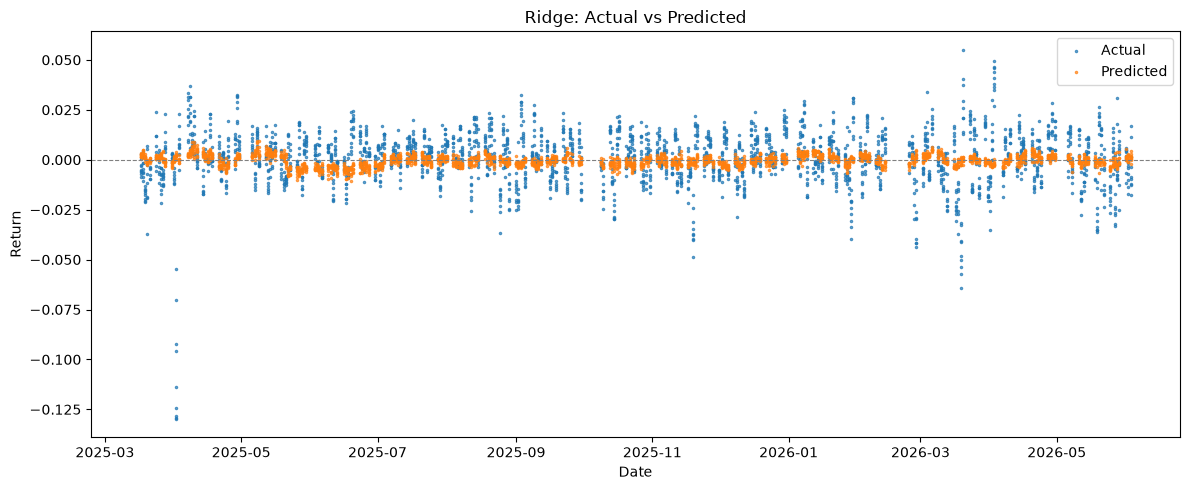

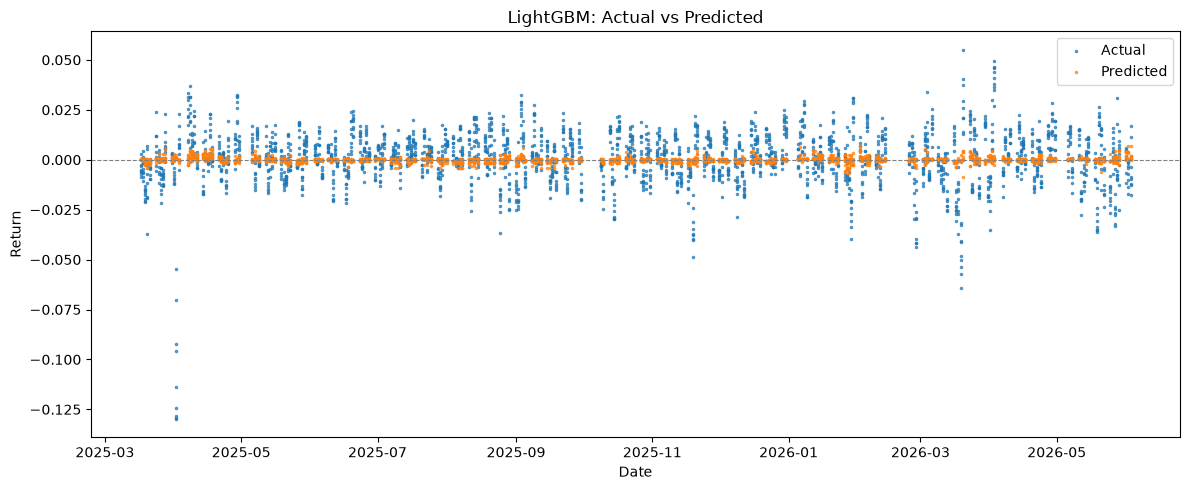

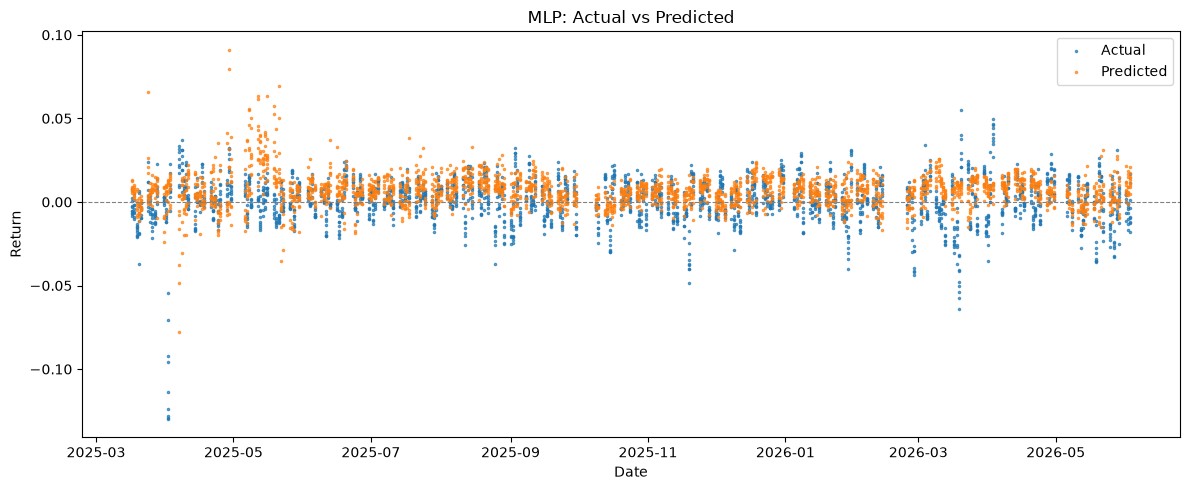

In [ ]:
X_fit = pd.concat([X_train, X_valid], axis=0)
y_fit = pd.concat([y_train, y_valid], axis=0)

preds_ridge, metrix_ridge = implement_ridge(X_fit, y_fit, X_test, y_test, best_alpha)
preds_lgb, metrix_lgb = implement_lgb(X_train, y_train, X_valid, y_valid, X_test, y_test, best_params_lgb)
preds_mlp, metrix_mlp = implement_mlp(X_fit, y_fit, X_test, y_test, best_params_mlp)
# preds_lstm, metrix_lstm = implement_lstm(X_train_seq, y_train_seq, X_valid_seq, y_valid_seq, X_test_seq, y_test_seq, best_params_lstm)

plot_actual_vs_predicted(y_test, preds_ridge, title= "Ridge: Actual vs Predicted")
plot_actual_vs_predicted(y_test, preds_lgb, title= "LightGBM: Actual vs Predicted")
plot_actual_vs_predicted(y_test, preds_mlp,  title= "MLP: Actual vs Predicted")
# plot_actual_vs_predicted(y_test_seq, preds_lstm)